<a href="https://colab.research.google.com/github/khanyisileplanga/Employee-Feedback-Project/blob/main/Employee_Feedback_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Level 1: Pandas (Data Handling Core)

*In this section, I am initializing the dataset. Raw data is often messy, so I use Pandas to structure the feedback as well as 'clean' the text to ensure consistency.*


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

raw_data = {
    'Employee_ID': range (100, 108),
    'Feedback': [
        "Management is doing a great job overall.",
        "Too many deadlines this month, the workload is too much",
        "I enjoy the team environment and the culture here!",
        "There are little to no growth opportunities or promotion paths here.",
        "Leadership needs to communicate more clearly.",
        "The workload is manageable but the pay is not enough.",
        "The deadlines are unrealistic for this project",
        "I want to grow more in the company and have more learning sessions."
    ]
}
df = pd.DataFrame(raw_data)

df['Clean_feedback'] = df['Feedback'].str.lower().str.strip()

df['Word_Count'] = df['Clean_feedback'].apply(lambda x: re.findall(r'\b\w+\b', x.lower()))



Level 2: NumPy (Logic + Computation)

*In this section , i am converting qualitative text into quantitative data. Which is why i built a custom sentiment scoring function that scans each comment for "Positive" or "Negative" keywords. Using NumPy, I can efficiently calculate the average sentiment score, providing a high-level metric of office morale.*

In [10]:
df['Word_Count'] = df['Clean_feedback'].apply(len)
pos_words = ['great', 'enjoy', 'supportive', 'growth']
neg_words = ['too', 'unrealistic', 'not', 'little']

def get_sentiment(words):
  score = 0
  for word in words :
    if word in pos_words:
      score += 1
    elif word in neg_words:
      score -= 1

  return score

df['Sentiment_Score'] = df['Clean_feedback'].apply(get_sentiment)
avg_score = np.mean(df['Sentiment_Score'])
print(f"The Office Average Sentiment is: {avg_score}")


The Office Average Sentiment is: 0.0


Level 3: Analysis (The Theme Engine)

*Sentiment tells us how people feel, but themes tell us why. I created a categorization engine using conditional logic to tag every comment with a specific business domain: Management, Workload, Culture, or Career Growth. This allows us to see exactly which issues are driving the feedback scores.*

In [11]:
def get_theme(text):
  text = ''.join(text)
  if 'management' in text or 'leadership' in text:
    return 'Management'
  elif 'workload' in text or 'deadlines' in text:
    return 'Workload'
  elif 'team' in text or 'culture' in text:
    return 'culture'
  elif 'growth' in text or 'promotion' in text:
    return 'career growth'
  else:
    return 'Other'

df['Theme'] = df['Clean_feedback'].apply(get_theme)
print(df[['Clean_feedback', 'Theme']])

                                      Clean_feedback          Theme
0           management is doing a great job overall.     Management
1  too many deadlines this month, the workload is...       Workload
2  i enjoy the team environment and the culture h...        culture
3  there are little to no growth opportunities or...  career growth
4      leadership needs to communicate more clearly.     Management
5  the workload is manageable but the pay is not ...       Workload
6     the deadlines are unrealistic for this project       Workload
7  i want to grow more in the company and have mo...          Other


Level 4: Matplotlib (Visualisation)

*Lastly*, *I used Matplotlib to create a dual-pane dashboard using plt.subplot.*


*   *The Left Chart shows the distribution of sentiment scores, giving us a "mood check" of the office*
*   *The Right chart highlights the most frequent themes discovered by the categorization engine*

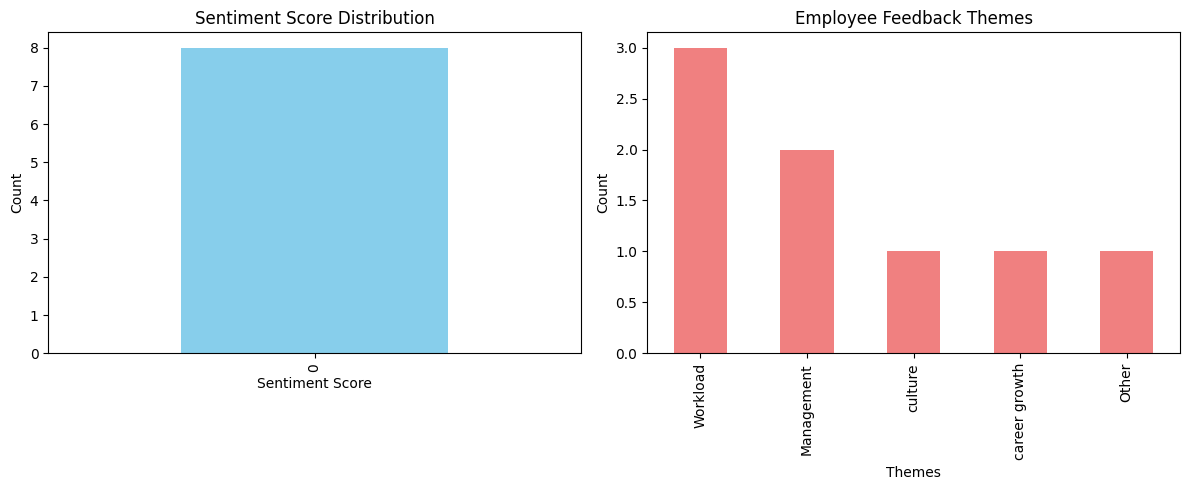

In [12]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df['Sentiment_Score'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Sentiment Score Distribution')
plt.xlabel('Sentiment Score')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
df['Theme'].value_counts().plot(kind='bar', color = 'lightcoral')
plt.title('Employee Feedback Themes')
plt.xlabel('Themes')
plt.ylabel('Count')

plt.tight_layout()
plt.show()